**Country Segmentation using K-Means and DBSCAN Clustering**

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

**Load the Dataset**

In [2]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**Basic Information**

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


**Strip Whitespace from Column Names**

In [4]:
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


**Remove Duplicate Records**

In [5]:
print("Duplicates Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicates After:", df.duplicated().sum())

Duplicates Before: 0
Duplicates After: 0


**Force Numeric Types and Handle Missing Values**

In [12]:
numeric_cols = df.columns.drop('country')
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


**Remove Country Identifier**

In [13]:
X = df.drop(columns=['country'])

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


**Scale Features**

In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


**Elbow Method (K = 2 to 10)**

In [15]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

**Plot Elbow Curve**

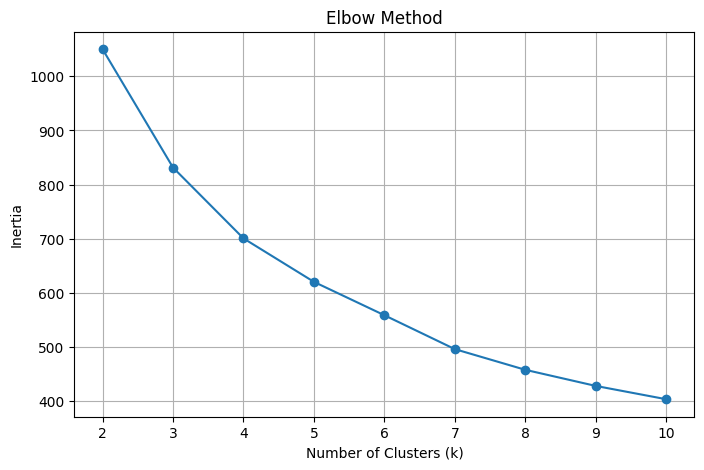

In [16]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

**Train K-Means (best_k = 3)**

In [17]:
best_k = 3

kmeans = KMeans(n_clusters=best_k,
                random_state=42,
                n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = clusters

df[['country','KMeans_Cluster']].head()

,country,KMeans_Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


**Silhouette Score**

In [18]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.2833


**DBSCAN Clustering**

In [19]:
dbscan = DBSCAN(eps=1.5,
                min_samples=5)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

print("DBSCAN Clusters:",
      np.unique(db_labels))

DBSCAN Clusters: [-1  0]


**PCA for 2D Projection**

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca,
                      columns=['PC1','PC2'])

pca_df["Cluster"] = clusters

**PCA Scatterplot**

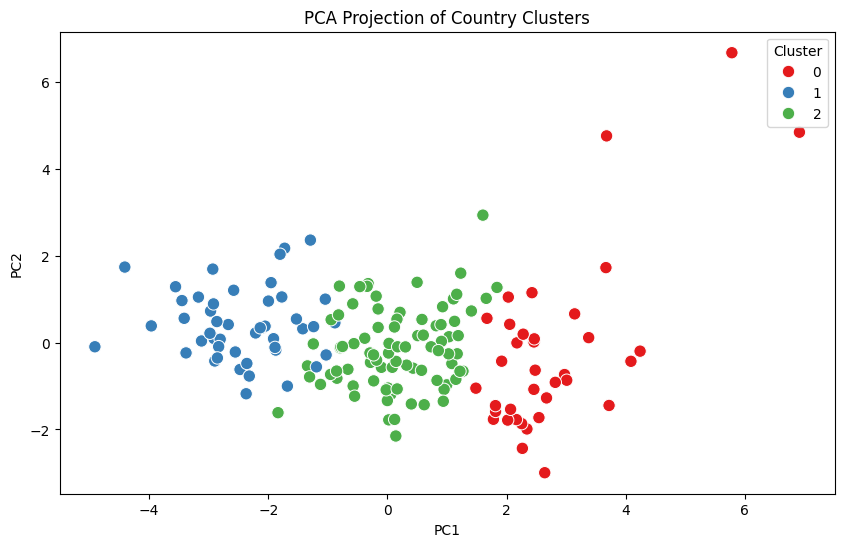

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title("PCA Projection of Country Clusters")

plt.show()

**Cluster Summary**

In [22]:
cluster_summary = df.groupby("KMeans_Cluster")[numeric_cols].mean()

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


**Observations**

Observation 1

Cluster 0 consists of countries with high income, high GDP per capita, and longer life expectancy, representing top-tier economic zones.

Observation 2

Cluster 1 contains countries with moderate socio-economic indicators and balanced development characteristics.

Observation 3

Cluster 2 is characterized by high child mortality rates, lower GDP, lower income levels, and shorter life expectancy, indicating low-development regions.

Observation 4

The positive Silhouette Score indicates that the chosen K-Means configuration forms reasonably stable and meaningful clusters.

Observation 5

The PCA scatterplot shows visible separation among the country groups, supporting the effectiveness of the clustering approach.